In [1]:
from tensorpac import Pac
import h5py
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.signal import welch

In [2]:
with h5py.File("../Data/data_LFP.mat", "r") as f:
    data_LFP_it = f['data_LFP_it']

    data_it = data_LFP_it['data_it'][()] 
    cm = data_LFP_it['cm'][()]            

print("data_it shape:", data_it.shape)
print("cm shape:", cm.shape)

data_it shape: (167, 1)
cm shape: (167, 1)


In [3]:
def dereference_array_of_refs(h5file, ref_array):
    result = []
    for ref in ref_array:
        if isinstance(ref, (np.ndarray,)):
            ref = ref.item()
        obj = h5file[ref]
        data = obj[()]
        result.append(data)
    return result

with h5py.File("../Data/data_LFP.mat", "r") as f:
    data_LFP_it = f['data_LFP_it']

    data_it_refs = data_LFP_it['data_it'][()]
    cm_refs = data_LFP_it['cm'][()]

    data_it_arrays = dereference_array_of_refs(f, data_it_refs)
    cm_arrays = dereference_array_of_refs(f, cm_refs)

print(f"Loaded {len(data_it_arrays)} elements in data_it")
print(f"Shape of first data_it element: {data_it_arrays[0].shape}")

print(f"Loaded {len(cm_arrays)} elements in cm")
print(f"Shape of first cm element: {cm_arrays[0].shape}")

Loaded 167 elements in data_it
Shape of first data_it element: (900, 818)
Loaded 167 elements in cm
Shape of first cm element: (1, 820)


In [4]:
mat = data_it_arrays
cm = cm_arrays

In [7]:
first_neuron = mat[5]
first_cm = cm[5]

In [9]:
first_cm  = first_cm[ : , : 818]
print(first_neuron.shape)
print(first_cm.shape)

(900, 818)
(1, 818)


Phase Amplitude Coupling object defined
Phase Amplitude Coupling object defined
    extract phases (n_pha=8) and amplitudes (n_amps=14)


Face: 900 trials


    true PAC estimation using Mean Vector Length (MVL, Canolty et al. 2006)
    compute surrogates (Swap amplitude time blocks (Bahramisharif et al. 2013), 200 permutations, random_state=3175)
    infer p-values at (p=0.05, mcp=maxstat)
    normalize true PAC estimation by surrogates (Substract the mean and divide by the deviation of the surrogates)


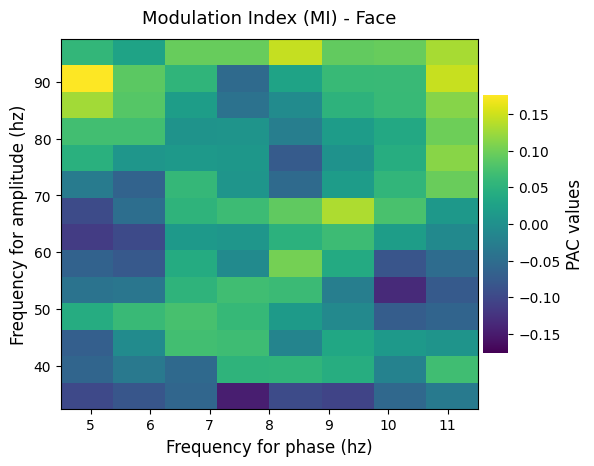

    extract phases (n_pha=8) and amplitudes (n_amps=14)
    true PAC estimation using Modulation Index (MI, Tort et al. 2010)
    compute surrogates (Swap amplitude time blocks (Bahramisharif et al. 2013), 200 permutations, random_state=2949)


KeyboardInterrupt: 

In [10]:
sf = 1000


category_labels = {
    "Artificial": [55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,74,96,97,98,99,100,101,123,124,125,126,127,128,150,151,152,153,154,155],
    "Body": [14,16,19,20,21,22,23,24,25,26,28,29,30,31,33,34,35,36,37,84,85,86,87,88,89,111,112,113,114,115,116,138,139,140,141,142,143],
    "Face": [1,2,3,4,5,6,7,8,9,10,11,12,13,15,17,18,27,75,76,77,78,79,80,83,102,103,104,105,106,107,110,129,130,131,132,133,134,137,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170],
    "Natural": [32,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,72,73,90,91,92,93,94,95,117,118,119,120,121,122,144,145,146,147,148,149]
}

first_cm = first_cm.flatten()


methods = {
    'Modulation Index (MI)': Pac(idpac=(1, 2, 4), f_pha=np.arange(4, 13, 1), f_amp=np.arange(30, 101, 5)),
    'Canolty Method': Pac(idpac=(2, 2, 4), f_pha=np.arange(4, 13, 1), f_amp=np.arange(30, 101, 5))
}

category_trials = defaultdict(list)
for idx, label in enumerate(first_cm):
    for category, labels in category_labels.items():
        if int(label) in labels:
            category_trials[category].append(idx)


for category, trials in category_trials.items():
    data = first_neuron[:, trials].T
    print(f"{category}: {data.shape[1]} trials")

    for method_name, pac in methods.items():
        xpac = pac.filterfit(sf, data, n_jobs=-1)
        mean_xpac = xpac.mean(-1)


        pac.comodulogram(mean_xpac, title=f"{method_name} - {category}", cmap='viridis', plotas='imshow')
        plt.show()


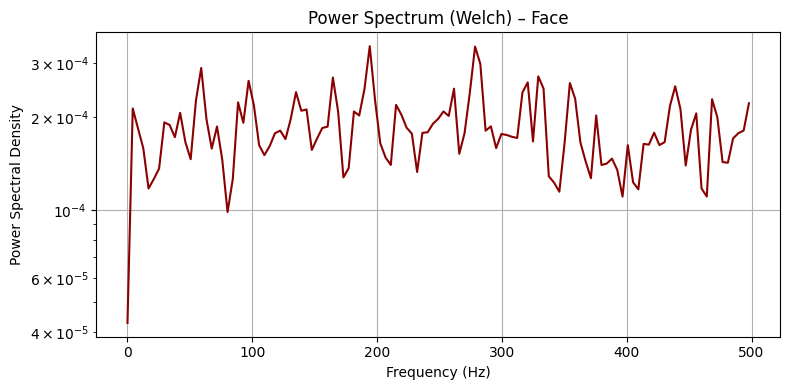

In [67]:
power_neuron = mat[1]
spectrum_category = 'Face'
spectrum_trials = category_trials[spectrum_category]
spectrum_data = power_neuron[:, spectrum_trials].T  # shape: (n_times, n_trials)

# Compute PSD across trials using Welch method
psds = []
for i in range(spectrum_data.shape[1]):  # loop over trials
    f, pxx = welch(spectrum_data[:, i], fs=sf, nperseg=sf)
    psds.append(pxx)

# Convert to array and average across trials
psds = np.array(psds)
pxx_mean = psds.mean(axis=0)

# Plot PSD
plt.figure(figsize=(8, 4))
plt.semilogy(f, pxx_mean, color='darkred')
plt.title(f'Power Spectrum (Welch) – {spectrum_category}')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.grid(True)
plt.tight_layout()
plt.show()